In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
df=pd.read_csv('/content/StudentPerformance.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29 entries, 0 to 28
Data columns (total 6 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Maths_Score            28 non-null     float64
 1   Reading_Score          27 non-null     float64
 2   Writing_Score          28 non-null     float64
 3   Placement_Score        27 non-null     float64
 4   Club_Join_Date         29 non-null     int64  
 5   Placement offer count  29 non-null     int64  
dtypes: float64(4), int64(2)
memory usage: 1.5 KB


In [ ]:
df.isnull().sum()

,0
Maths_Score,1
Reading_Score,2
Writing_Score,1
Placement_Score,2
Club_Join_Date,0
Placement offer count,0


In [ ]:
mean_val=df['Maths_Score'].mean()
df['Maths_Score']=df['Maths_Score'].fillna(mean_val)
mean_val=df['Reading_Score'].mean()
df['Reading_Score']=df['Reading_Score'].fillna(mean_val)
mean_val=df['Writing_Score'].mean()
df['Writing_Score']=df['Writing_Score'].fillna(mean_val)
mean_val=df['Placement_Score'].mean()
df['Placement_Score']=df['Placement_Score'].fillna(mean_val)
df.isnull().sum()

,0
Maths_Score,0
Reading_Score,0
Writing_Score,0
Placement_Score,0
Club_Join_Date,0
Placement offer count,0


<Axes: >

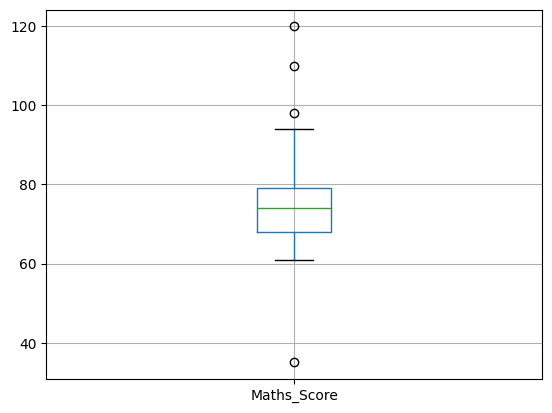

In [ ]:
col=['Maths_Score']
df.boxplot(col)

In [ ]:
sorted_df=sorted(df['Maths_Score'])
sorted_df
q1=np.percentile(sorted_df,25)
q3=np.percentile(sorted_df,75)
print(q1,q3)

68.0 79.0


In [ ]:
IQR=q3-q1
lwr_bound=q1-(1.5*IQR)
upr_bound=q3+(1.5*IQR)
print(lwr_bound,upr_bound)

51.5 95.5


In [ ]:
sample_outliers=df[col][(df[col]<lwr_bound)|(df[col]>upr_bound)]
sample_outliers

,Maths_Score
0,NaN
1,NaN
2,NaN
3,35.0
4,NaN
5,NaN
6,NaN
7,NaN
8,NaN
9,NaN


In [ ]:
median=np.median(df[col])
median

np.float64(74.0)

In [ ]:
index_outliers = sample_outliers['Maths_Score'].dropna().index
for i in index_outliers:
  df.loc[i, col[0]] = median
df

,Maths_Score,Reading_Score,Writing_Score,Placement_Score,Club_Join_Date,Placement offer count
0,70.0,93.000000,61.000000,82.000000,2020,2
1,77.0,84.000000,65.000000,88.000000,2019,3
2,69.0,84.000000,68.000000,93.000000,2020,3
3,74.0,81.000000,73.000000,91.000000,2019,3
4,78.0,95.000000,73.000000,96.000000,2020,3
5,70.0,94.000000,60.000000,80.000000,2020,2
6,69.0,86.000000,79.000000,91.000000,2018,3
7,76.0,92.000000,61.000000,79.000000,2019,2
8,79.0,81.000000,77.000000,80.000000,2018,2
9,79.0,85.000000,78.000000,76.000000,2020,2
